<a href="https://colab.research.google.com/github/Toandinh1/Dartmouth_Probation_8weeks/blob/main/Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install numpy scipy scikit-learn matplotlib tensorflow kagglehub

In [ ]:
pip install -U "tf-keras~=2.16" tensorflow-model-optimization


In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_model_optimization as tfmot


In [ ]:
print("tf:", tf.__version__)
print("tf.keras module file:", tf.keras.__file__)
# In legacy mode, tf.keras will point to tf_keras (not keras/src)


tf: 2.20.0
tf.keras module file: /usr/local/lib/python3.12/dist-packages/tf_keras/api/_v2/keras/__init__.py


In [ ]:
import os
import pickle
import random
import numpy as np
from dataclasses import dataclass
from typing import Dict, List, Tuple

from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, callbacks

In [ ]:
@dataclass
class Config:
    data_root: str = ".../WESAD"      # folder containing subject folders like S2, S3, ...
    seed: int = 42

    # PPG sampling rate in WESAD depends on device:
    # - Chest RESPI/ECG etc are different
    # - Wrist BVP (PPG) is typically 64 Hz in many WESAD distributions (Empatica E4)
    ppg_fs: int = 64

    #filter type
    filter_type: str = "none"

    # windowing
    win_sec: int = 8               # 8s windows is common for physio
    hop_sec: int = 2               # overlap improves sample count

    # label setup: choose a simple target for Week 2
    # Option A (binary): stress (label=2) vs non-stress (baseline+amusement)
    # Option B (3-class): baseline vs stress vs amusement
    task: str = "binary"           # "binary" or "3class"

    #number CNN blocks to evaluate trade-off
    num_blocks: int = 3

    # filtering_bandpass
    use_bandpass: bool = True
    f1: float = 0.5            # Hz lowest
    f2: float = 8.0           # Hz (PPG heart-related band) highest
    bp_order: int = 3
    zero_phase = True

    #EMA
    alpha = 0.1

    #Median

    k = 3 # 5 for "moving_average"

    #baseline removal

    fs = 64
    #have to fix some argument for other filter

    # split
    train_ratio: float = 0.6
    val_ratio: float = 0.2         # rest is test

    # models
    rf_n_estimators: int = 300
    svm_c: float = 3.0
    svm_gamma: str = "scale"


cfg = Config()

In [ ]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed(cfg.seed)

In [ ]:
### Filtering ###
from typing import Optional
import numpy as np

def apply_filter(
    x: np.ndarray,
    fs: Optional[int] = None,
    kind: str = "none",
    f1: Optional[float] = None,
    f2: Optional[float] = None,
    order: int = 3,
    k: int = 3,
    alpha: float = 0.1,
    zero_phase: bool = True,
    q: float = 30.0,
) -> np.ndarray:
    """

    Parameters
    ----------
    x : np.ndarray
        1D signal (PPG).
    fs : int
        Sampling frequency (required for frequency-based filters).
    kind : str
        Filter type:
          - "none"
          - Offline (SciPy): "bandpass", "lowpass", "highpass", "notch"
          - MCU-friendly: "ema", "median", "moving_average", "hp1"
    f1 : float
        For bandpass: low cutoff (Hz)
        For lowpass/highpass/notch: cutoff or notch frequency (Hz)
    f2 : float
        For bandpass: high cutoff (Hz)
    order : int
        Butterworth order for SciPy filters.
    k : int
        Kernel size for median / moving average (odd for median).
    alpha : float
        EMA smoothing factor in (0,1].
    zero_phase : bool
        If True, use filtfilt (offline only). If False, use lfilter (causal).
    q : float
        Notch filter quality factor (higher = narrower notch).

    Returns
    -------
    np.ndarray
        Filtered signal, float32.
    """
    x = np.asarray(x, dtype=np.float32)
    if x.ndim != 1:
        raise ValueError("apply_filter expects a 1D array.")

    kind = kind.lower().strip()
    if kind in ("none", ""):
        return x.astype(np.float32)

    # -------------------------
    # MCU-friendly filters
    # -------------------------
    if kind == "ema":
        y = np.empty_like(x)
        y0 = x[0]
        y[0] = y0
        for i in range(1, len(x)):
            y0 = alpha * x[i] + (1.0 - alpha) * y0
            y[i] = y0
        return y.astype(np.float32)

    if kind == "median":
        if k % 2 != 1 or k < 3:
            raise ValueError("median filter requires odd k >= 3.")
        y = np.empty_like(x)
        buf = np.zeros(k, dtype=np.float32)
        for i in range(len(x)):
            buf[:-1] = buf[1:]
            buf[-1] = x[i]
            y[i] = np.median(buf)
        return y.astype(np.float32)

    if kind == "moving_average":
        if k < 2:
            raise ValueError("moving_average requires k >= 2.")
        y = np.empty_like(x)
        buf = np.zeros(k, dtype=np.float32)
        s = 0.0
        idx = 0
        for i in range(len(x)):
            s -= buf[idx]
            buf[idx] = x[i]
            s += buf[idx]
            idx = (idx + 1) % k
            y[i] = s / min(i + 1, k)  # warm-up
        return y.astype(np.float32)

    if kind == "hp1":
        # 1st-order IIR high-pass: good MCU baseline drift removal
        if fs is None or f1 is None:
            raise ValueError("hp1 requires fs and f1 (cutoff Hz).")
        dt = 1.0 / float(fs)
        RC = 1.0 / (2.0 * np.pi * float(f1))
        a = RC / (RC + dt)

        y = np.empty_like(x)
        y0 = 0.0
        x_prev = x[0]
        y[0] = 0.0
        for i in range(1, len(x)):
            y0 = a * (y0 + x[i] - x_prev)
            y[i] = y0
            x_prev = x[i]
        return y.astype(np.float32)

    # -------------------------
    # SciPy frequency filters (offline / optional)
    # -------------------------
    if kind in ("bandpass", "lowpass", "highpass", "notch"):
        if fs is None:
            raise ValueError(f"{kind} requires fs.")
        try:
            from scipy.signal import butter, filtfilt, lfilter, iirnotch
        except Exception as e:
            raise ImportError("SciPy is required for butter/notch filters.") from e

        if kind == "notch":
            if f1 is None:
                raise ValueError("notch requires f1 (notch frequency in Hz).")
            b, a = iirnotch(w0=float(f1), Q=float(q), fs=float(fs))
            return (filtfilt(b, a, x) if zero_phase else lfilter(b, a, x)).astype(np.float32)

        nyq = 0.5 * float(fs)

        if kind == "bandpass":
            if f1 is None or f2 is None:
                raise ValueError("bandpass requires f1 (low Hz) and f2 (high Hz).")
            lowc = float(f1) / nyq
            highc = float(f2) / nyq
            b, a = butter(order, [lowc, highc], btype="band")
        elif kind == "lowpass":
            if f1 is None:
                raise ValueError("lowpass requires f1 (cutoff Hz).")
            wc = float(f1) / nyq
            b, a = butter(order, wc, btype="low")
        elif kind == "highpass":
            if f1 is None:
                raise ValueError("highpass requires f1 (cutoff Hz).")
            wc = float(f1) / nyq
            b, a = butter(order, wc, btype="high")
        else:
            raise ValueError(f"Unsupported SciPy filter kind: {kind}")

        return (filtfilt(b, a, x) if zero_phase else lfilter(b, a, x)).astype(np.float32)

    pass


In [ ]:
# =========================
# Utilities: windowing
# =========================

def sliding_window(x: np.ndarray, y: np.ndarray, fs: int, win_sec: int, hop_sec: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create windows from signal x and label y (sample-aligned).
    Label per window is majority label within window.
    """
    win = win_sec * fs
    hop = hop_sec * fs
    assert len(x) == len(y), "Signal and label must have same length."

    Xw, Yw = [], []
    for start in range(0, len(x) - win + 1, hop):
        end = start + win
        xseg = x[start:end]
        yseg = y[start:end]
        # majority label
        label = np.bincount(yseg.astype(int)).argmax()
        Xw.append(xseg)
        Yw.append(label)

    return np.stack(Xw, axis=0), np.array(Yw, dtype=np.int64)

In [ ]:
# =========================
# Feature extraction for classical baseline
# =========================

def window_features(ppg_win: np.ndarray, fs: int) -> np.ndarray:
    """
    Simple, robust time-domain features for baseline model.
    """
    x = ppg_win.astype(np.float32)

    # basic stats
    mean = np.mean(x)
    std = np.std(x) + 1e-8
    mn = np.min(x)
    mx = np.max(x)
    rng = mx - mn
    med = np.median(x)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)

    # shape-ish features
    rms = np.sqrt(np.mean(x**2))
    zcr = np.mean(np.diff(np.sign(x)) != 0)  # zero-crossing rate proxy
    # energy in band (rough)
    energy = np.mean(x**2)

    # normalized derivative stats
    dx = np.diff(x)
    dx_mean = np.mean(dx)
    dx_std = np.std(dx) + 1e-8

    return np.array([mean, std, mn, mx, rng, med, iqr, rms, zcr, energy, dx_mean, dx_std], dtype=np.float32)


def extract_features(Xw: np.ndarray, fs: int) -> np.ndarray:
    feats = [window_features(w, fs) for w in Xw]
    return np.stack(feats, axis=0)

In [ ]:
# =========================
# WESAD loader (PPG-only)
# =========================

def list_subjects(data_root: str) -> List[str]:
    subs = []
    for name in os.listdir(data_root):
        if name.startswith("S") and os.path.isdir(os.path.join(data_root, name)):
            subs.append(name)
    subs = sorted(subs)
    if not subs:
        raise FileNotFoundError(f"No subject folders like 'S2' found in {data_root}")
    return subs


def load_subject_wesad_ppg(subject_dir: str) -> Tuple[np.ndarray, np.ndarray, int]:
    """
    Returns:
      ppg: (T,) float32
      labels: (T,) int64 sample-level labels aligned to ppg
      fs: sampling rate (Hz)
    """
    # ---- (1) locate pkl file ----
    pkl_candidates = []
    for root, _, files in os.walk(subject_dir):
        for f in files:
            if f.endswith(".pkl"):
                pkl_candidates.append(os.path.join(root, f))
    if not pkl_candidates:
        raise FileNotFoundError(f"No .pkl found under {subject_dir}")

    pkl_path = pkl_candidates[0]  # pick first; if multiple, choose correctly
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    # ---- (2) extract PPG (BVP) signal ----
    try:
        ppg = data["signal"]["wrist"]["BVP"].reshape(-1).astype(np.float32)
    except Exception as e:
        raise KeyError(
            "Cannot find PPG at data['signal']['wrist']['BVP']. "
            "Please print(data.keys()) and inspect your structure."
        ) from e

    # ---- (3) extract labels aligned to PPG sampling ----
    try:
        labels = data["label"].reshape(-1).astype(np.int64)
    except Exception as e:
        raise KeyError(
            "Cannot find labels at data['label']. "
            "Please inspect your pickle structure."
        ) from e

    fs = cfg.ppg_fs

    # ---- (4) ensure alignment ----
    if len(labels) != len(ppg):
        # Simple nearest-neighbor stretch (good enough for Week 2 if mismatch is monotonic).
        idx = np.linspace(0, len(labels) - 1, num=len(ppg)).round().astype(int)
        labels = labels[idx]

    return ppg, labels, fs


def map_labels(y: np.ndarray, task: str) -> np.ndarray:
    """
    WESAD typical labels:
      1 = baseline
      2 = stress
      3 = amusement
      4 = meditation (in some versions)
      0 = undefined/transition sometimes

    We remove undefined/transition labels (0) by filtering.
    """
    y = y.astype(np.int64)

    # filter out 0 (undefined) and optionally other labels not used
    valid = np.isin(y, [1, 2, 3])
    y = y[valid]

    if task == "binary":
        # stress vs non-stress (baseline+amusement)
        y_bin = np.where(y == 2, 1, 0).astype(np.int64)
        return y_bin
    elif task == "3class":
        # map 1->0 baseline, 2->1 stress, 3->2 amusement
        mapping = {1: 0, 2: 1, 3: 2}
        return np.vectorize(mapping.get)(y).astype(np.int64)
    else:
        raise ValueError("task must be 'binary' or '3class'")

In [ ]:
# =========================
# Build dataset
# =========================

def build_subject_windows(subject_dir: str) -> Tuple[np.ndarray, np.ndarray]:
    ppg, labels, fs = load_subject_wesad_ppg(subject_dir)

    # filter
    ppg = apply_filter(ppg, fs=cfg.ppg_fs, kind=cfg.filter_type, f1=cfg.f1, f2=cfg.f2,
                 order=cfg.bp_order, k=cfg.k, alpha=cfg.alpha, zero_phase=cfg.zero_phase)

    # Filter labels first to drop invalid segments (e.g., label 0)
    valid_mask = np.isin(labels, [1, 2, 3])
    ppg = ppg[valid_mask]
    labels = labels[valid_mask]

    # remap labels (binary or 3-class)
    y = map_labels(labels, cfg.task)

    # windowing
    Xw, Yw = sliding_window(ppg, y, fs, cfg.win_sec, cfg.hop_sec)

    return Xw, Yw


def split_subjects(subjects: List[str], train_ratio: float, val_ratio: float, seed: int):
    rng = np.random.RandomState(seed)
    subs = subjects.copy()
    rng.shuffle(subs)

    n = len(subs)
    n_train = int(round(n * train_ratio))
    n_val = int(round(n * val_ratio))
    n_test = n - n_train - n_val

    train_subs = subs[:n_train]
    val_subs = subs[n_train:n_train + n_val]
    test_subs = subs[n_train + n_val:]

    assert len(set(train_subs) & set(val_subs)) == 0
    assert len(set(train_subs) & set(test_subs)) == 0
    assert len(set(val_subs) & set(test_subs)) == 0

    return train_subs, val_subs, test_subs


def build_split_arrays(data_root: str):
    subjects = list_subjects(data_root)
    train_subs, val_subs, test_subs = split_subjects(subjects, cfg.train_ratio, cfg.val_ratio, cfg.seed)

    def collect(sub_list):
        X_all, y_all = [], []
        for s in sub_list:
            subject_dir = os.path.join(data_root, s)
            Xw, Yw = build_subject_windows(subject_dir)
            X_all.append(Xw)
            y_all.append(Yw)
        return np.concatenate(X_all, axis=0), np.concatenate(y_all, axis=0)

    X_train, y_train = collect(train_subs)
    X_val, y_val = collect(val_subs)
    X_test, y_test = collect(test_subs)

    print("Subjects:", subjects)
    print("Train subjects:", train_subs)
    print("Val subjects:", val_subs)
    print("Test subjects:", test_subs)
    print("Shapes:", X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

In [ ]:
# =========================
# Classical baseline: SVM / RF
# =========================

def train_eval_classical(X_train, y_train, X_val, y_val, X_test, y_test):
    # Features
    F_train = extract_features(X_train, cfg.ppg_fs)
    F_val = extract_features(X_val, cfg.ppg_fs)
    F_test = extract_features(X_test, cfg.ppg_fs)

    # Choose ONE baseline: SVM (strong) or RF (stable)
    kernel_svm = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(C=cfg.svm_c, gamma=cfg.svm_gamma, kernel="rbf"))
    ])

    linear_svm = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=cfg.svm_c))
    ])

    rf = Pipeline([
        ("scaler", StandardScaler()),  # optional for RF, kept for consistency
        ("clf", RandomForestClassifier(
            n_estimators=cfg.rf_n_estimators,
            random_state=cfg.seed,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])

    models = {
        "SVM(RBF)": kernel_svm,
        "LinearSVM": linear_svm,
        "RandomForest": rf
    }

    results = {}
    for name, model in models.items():
        model.fit(F_train, y_train)

        # Validate
        yv_pred = model.predict(F_val)
        val_acc = accuracy_score(y_val, yv_pred)
        val_f1 = f1_score(y_val, yv_pred, average="macro")

        # Test
        yt_pred = model.predict(F_test)
        test_acc = accuracy_score(y_test, yt_pred)
        test_f1 = f1_score(y_test, yt_pred, average="macro")
        cm = confusion_matrix(y_test, yt_pred)

        results[name] = {
            "val_acc": val_acc, "val_f1": val_f1,
            "test_acc": test_acc, "test_f1": test_f1,
            "cm": cm,
            "report": classification_report(y_test, yt_pred, digits=4)
        }

    return results

In [ ]:
# =========================
# Deep baseline: small 1D CNN on raw PPG windows
# + DSConv option (Depthwise Separable Conv1D via SeparableConv1D)
# =========================
import math
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# ---- (Optional) SE code kept but not used; you can delete later ----
def _se_block_1d(x, *, se_ratio: int = 16, se_activation: str = "relu", name: str = "se"):
    c = x.shape[-1]
    if c is None:
        raise ValueError("Channel dim must be known for SE.")
    s = layers.GlobalAveragePooling1D(name=f"{name}_gap")(x)
    hidden = max(1, int(c) // int(se_ratio))
    e = layers.Dense(hidden, activation=se_activation, name=f"{name}_fc1")(s)
    e = layers.Dense(int(c), activation="sigmoid", name=f"{name}_fc2")(e)
    e = layers.Reshape((1, int(c)), name=f"{name}_reshape")(e)
    return layers.Multiply(name=f"{name}_scale")([x, e])


def build_cnn_1d(
    input_len: int,
    n_classes: int,
    n_blocks: int,
    *,
    # --- Architecture control ---
    filters=None,               # list[int] length = n_blocks (overrides base_filters/growth)
    kernels=None,               # list[int] length = n_blocks (or shorter -> repeated)
    base_filters: int = 16,
    filter_growth: float = 2.0,
    min_filters: int = 8,
    max_filters: int = 256,
    activation: str = "relu",
    # pooling
    use_maxpool: bool = True,
    pool_size: int = 2,
    pool_every: int = 1,
    pool_mode: str = "same",
    # normalization / regularization
    use_bn: bool = True,
    bn_momentum: float = 0.99,
    bn_epsilon: float = 1e-3,
    dropout: float = 0.2,       # after GAP
    dense_units=None,
    dense_dropout: float = 0.0,
    l2: float = 0.0,

    # --- NEW: Conv type control ---
    conv_type: str = "standard",   # "standard" | "dsconv"
    ds_pointwise_activation: bool = False,  # keep False to match Conv->BN->Act pattern

    # --- Compile control ---
    lr: float = 1e-3,
    loss: str = "sparse_categorical_crossentropy",
    metrics=("accuracy",),
    name: str = None,
):
    """
    1D-CNN builder supporting:
      - standard Conv1D blocks
      - depthwise separable Conv1D blocks (via SeparableConv1D)

    Block pattern (both):
      Conv -> (BN) -> Act -> (Pool)
    """
    if n_blocks < 1:
        raise ValueError("n_blocks must be >= 1")
    if conv_type not in ("standard", "dsconv"):
        raise ValueError("conv_type must be 'standard' or 'dsconv'")

    reg = regularizers.l2(l2) if l2 and l2 > 0 else None

    # --- build filters schedule ---
    if filters is None:
        filt = []
        for i in range(n_blocks):
            f = int(round(base_filters * (filter_growth ** i)))
            f = max(min_filters, min(max_filters, f))
            filt.append(f)
        filters = filt
    else:
        if len(filters) != n_blocks:
            raise ValueError(f"`filters` must have length {n_blocks}")

    # --- build kernels schedule ---
    if kernels is None:
        base = [7, 5, 5]
        kernels = base[:n_blocks] if n_blocks <= len(base) else base + [3] * (n_blocks - len(base))
    kernels = list(kernels)
    if len(kernels) < n_blocks:
        kernels += [kernels[-1]] * (n_blocks - len(kernels))
    elif len(kernels) > n_blocks:
        kernels = kernels[:n_blocks]

    if dense_units is None:
        dense_units = int(filters[-1])

    x_in = layers.Input(shape=(input_len, 1), name="x_in")
    x = x_in
    cur_len = input_len

    for i in range(n_blocks):
        f = int(filters[i])
        k = int(kernels[i])

        # ----- Conv layer: standard vs DSConv -----
        if conv_type == "standard":
            x = layers.Conv1D(
                filters=f,
                kernel_size=k,
                padding="same",
                use_bias=not use_bn,
                kernel_regularizer=reg,
                name=f"conv_{i+1}",
            )(x)
        else:
            # SeparableConv1D = depthwise conv + pointwise conv
            x = layers.SeparableConv1D(
                filters=f,              # output channels after pointwise
                kernel_size=k,
                padding="same",
                use_bias=not use_bn,
                depthwise_regularizer=reg,
                pointwise_regularizer=reg,
                name=f"dsconv_{i+1}",
            )(x)
            # optional extra nonlinearity between depthwise and pointwise is NOT available
            # in Keras SeparableConv1D; keep the same BN->Act pattern after.

        # BN
        if use_bn:
            x = layers.BatchNormalization(
                momentum=bn_momentum,
                epsilon=bn_epsilon,
                name=f"bn_{i+1}",
            )(x)

        # Activation
        x = layers.Activation(activation, name=f"act_{i+1}")(x)

        # Pooling
        do_pool = use_maxpool and (pool_every > 0) and ((i + 1) % pool_every == 0)
        if do_pool:
            if pool_mode == "safe":
                if cur_len >= pool_size * 2:
                    x = layers.MaxPool1D(pool_size=pool_size, name=f"pool_{i+1}")(x)
                    cur_len = math.ceil(cur_len / pool_size)
            else:
                x = layers.MaxPool1D(pool_size=pool_size, name=f"pool_{i+1}")(x)
                cur_len = max(1, math.ceil(cur_len / pool_size))

    x = layers.GlobalAveragePooling1D(name="gap")(x)

    if dropout and dropout > 0:
        x = layers.Dropout(dropout, name="dropout")(x)

    x = layers.Dense(
        int(dense_units),
        activation=activation,
        kernel_regularizer=reg,
        name="fc",
    )(x)

    if dense_dropout and dense_dropout > 0:
        x = layers.Dropout(dense_dropout, name="dense_dropout")(x)

    out = layers.Dense(n_classes, activation="softmax", name="pred")(x)

    suffix = "dsconv" if conv_type == "dsconv" else "base"
    model_name = name or f"cnn1d_{suffix}_blocks{n_blocks}"
    model = models.Model(x_in, out, name=model_name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=loss,
        metrics=list(metrics),
    )
    return model


def train_eval_cnn(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    number_cnn: int,
    *,
    conv_type: str = "standard",   # "standard" or "dsconv"
    # training knobs
    epochs: int = 50,
    batch_size: int = 128,
    lr: float = 1e-3,
    verbose: int = 2,
):
    """
    Train + evaluate baseline vs DSConv 1D-CNN.
    Normalizes using TRAIN stats only.
    Adds channel dim for Conv1D: (B, T) -> (B, T, 1)
    """
    if X_train.ndim != 2:
        raise ValueError(f"Expected X_train shape (B, T). Got {X_train.shape}")

    mean = float(np.mean(X_train))
    std = float(np.std(X_train)) + 1e-8

    X_train_n = ((X_train - mean) / std)[..., None].astype(np.float32)
    X_val_n   = ((X_val   - mean) / std)[..., None].astype(np.float32)
    X_test_n  = ((X_test  - mean) / std)[..., None].astype(np.float32)

    input_len = int(X_train.shape[1])
    n_classes = int(np.max(y_train)) + 1

    model = build_cnn_1d(
        input_len=input_len,
        n_classes=n_classes,
        n_blocks=number_cnn,
        conv_type=conv_type,
        lr=lr,
        name=f"cnn1d_{'ds' if conv_type=='dsconv' else 'base'}_blocks{number_cnn}",
    )

    cb = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=5,
            min_delta=1e-3,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_accuracy",
            mode="max",
            factor=0.5,
            patience=2,
            min_delta=1e-3,
            cooldown=1,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        X_train_n, y_train,
        validation_data=(X_val_n, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=cb
    )

    y_test_prob = model.predict(X_test_n, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average="macro")
    cm       = confusion_matrix(y_test, y_test_pred)
    report   = classification_report(y_test, y_test_pred, digits=4)

    results = {
        "conv_type": conv_type,
        "norm_mean": mean,
        "norm_std": std,
        "test_acc": float(test_acc),
        "test_f1": float(test_f1),
        "cm": cm,
        "report": report,
    }
    return model, history, results


In [ ]:
import os
import kagglehub

path = kagglehub.dataset_download("orvile/wesad-wearable-stress-affect-detection-dataset")
print("Path to dataset files:", path)
print("Top-level files:", os.listdir(path)[:20])

Using Colab cache for faster access to the 'wesad-wearable-stress-affect-detection-dataset' dataset.
Path to dataset files: /kaggle/input/wesad-wearable-stress-affect-detection-dataset
Top-level files: ['WESAD']


In [ ]:
def find_subject_root(base_path: str):
    # Candidate roots to try
    candidates = [
        base_path,
        os.path.join(base_path, "WESAD"),
        os.path.join(base_path, "WESAD", "WESAD"),
    ]
    # Also scan one level deep (robust to different Kaggle pack structures)
    for name in os.listdir(base_path):
        p = os.path.join(base_path, name)
        if os.path.isdir(p):
            candidates.append(p)

    for c in candidates:
        if os.path.isdir(c):
            subs = [d for d in os.listdir(c) if d.startswith("S") and os.path.isdir(os.path.join(c, d))]
            if len(subs) > 0:
                return c, sorted(subs)

    raise FileNotFoundError(f"Could not find subject folders (S2, S3, ...) under: {base_path}")

import os
data_root, subjects = find_subject_root(path)
print("✅ Detected data_root:", data_root)
print("✅ Example subjects:", subjects[:10], " total:", len(subjects))


✅ Detected data_root: /kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD
✅ Example subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4']  total: 15


In [ ]:
cfg.data_root = data_root
(X_train, y_train), (X_val, y_val), (X_test, y_test) = build_split_arrays(cfg.data_root)

Subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Train subjects: ['S4', 'S6', 'S10', 'S8', 'S16', 'S3', 'S13', 'S11', 'S9']
Val subjects: ['S15', 'S2', 'S5']
Test subjects: ['S7', 'S14', 'S17']
Shapes: (9910, 512) (9910,) (3275, 512) (3275,) (3341, 512) (3341,)


In [ ]:
# ============================================================
# Robustness sweeps: Gaussian noise (sigma * std) + missing data
# Drop-in extension around your existing training pipeline
# - Trains CNN once (clean)
# - Evaluates on noisy/missing versions of X_test (and optionally X_val)
# - Produces a results table + a couple plots
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# -----------------------------
# Helpers: model prediction -> metrics
# -----------------------------
def _predict_labels_binary(model, X, threshold=0.5, batch_size=256):
    """
    Works for:
    - sigmoid output shape (N,1)
    - softmax output shape (N,2)
    Returns int labels {0,1}.
    """
    yhat = model.predict(X, batch_size=batch_size, verbose=0)
    yhat = np.asarray(yhat)

    if yhat.ndim == 2 and yhat.shape[1] == 1:
        prob1 = yhat[:, 0]
        return (prob1 >= threshold).astype(np.int32)

    if yhat.ndim == 2 and yhat.shape[1] == 2:
        return np.argmax(yhat, axis=1).astype(np.int32)

    # fallback: squeeze then threshold
    yhat = np.squeeze(yhat)
    return (yhat >= threshold).astype(np.int32)

def eval_model_binary(model, X, y, name="eval"):
    yp = _predict_labels_binary(model, X)
    acc = accuracy_score(y, yp)
    f1 = f1_score(y, yp, average="binary")
    cm = confusion_matrix(y, yp)
    rep = classification_report(y, yp, digits=4)
    return {
        "name": name,
        "acc": float(acc),
        "f1": float(f1),
        "cm": cm,
        "report": rep,
    }

# -----------------------------
# Gaussian noise
# -----------------------------
def apply_gaussian_noise(X, sigma_scale, rng=None):
    """
    sigma = sigma_scale * std(X) computed per-sample window (recommended for robustness)
    X shape: (N, T, C) or (N, T)
    """
    if rng is None:
        rng = np.random.default_rng(42)

    Xn = np.array(X, copy=True)

    if Xn.ndim == 2:
        # (N,T)
        std = Xn.std(axis=1, keepdims=True) + 1e-8
        sigma = sigma_scale * std
        noise = rng.normal(0.0, 1.0, size=Xn.shape) * sigma
        return Xn + noise

    if Xn.ndim == 3:
        # (N,T,C)
        std = Xn.std(axis=1, keepdims=True) + 1e-8  # std over time per channel
        sigma = sigma_scale * std
        noise = rng.normal(0.0, 1.0, size=Xn.shape) * sigma
        return Xn + noise

    raise ValueError(f"Unsupported X ndim={Xn.ndim}")

# -----------------------------
# Missing data: random drop + burst drop
# Strategies: zero, hold, interp
# -----------------------------
def _fill_missing_1d(x, mask, mode="zero"):
    """
    x: (T,) float
    mask: (T,) bool, True = missing
    """
    x2 = x.copy()

    if mode == "zero":
        x2[mask] = 0.0
        return x2

    if mode == "hold":
        # forward fill; if starts missing, backward fill from first non-missing
        idx = np.arange(len(x2))
        good = ~mask
        if not np.any(good):
            return np.zeros_like(x2)

        # forward fill
        last = None
        for i in range(len(x2)):
            if good[i]:
                last = x2[i]
            else:
                if last is not None:
                    x2[i] = last

        # backward fill for leading missings
        if mask[0]:
            first_good = np.argmax(good)
            x2[:first_good] = x2[first_good]
        return x2

    if mode == "interp":
        good = ~mask
        if not np.any(good):
            return np.zeros_like(x2)
        xp = np.flatnonzero(good)
        fp = x2[good]
        x2[mask] = np.interp(np.flatnonzero(mask), xp, fp).astype(x2.dtype)
        return x2

    raise ValueError("mode must be one of: zero, hold, interp")

def apply_random_drop(X, drop_p, mode="zero", rng=None):
    """
    Randomly marks p% samples as missing along time axis.
    X: (N,T) or (N,T,C)
    """
    if rng is None:
        rng = np.random.default_rng(42)

    Xd = np.array(X, copy=True)

    if Xd.ndim == 2:
        N, T = Xd.shape
        for n in range(N):
            mask = rng.random(T) < drop_p
            Xd[n] = _fill_missing_1d(Xd[n], mask, mode=mode)
        return Xd

    if Xd.ndim == 3:
        N, T, C = Xd.shape
        for n in range(N):
            mask = rng.random(T) < drop_p
            for c in range(C):
                Xd[n, :, c] = _fill_missing_1d(Xd[n, :, c], mask, mode=mode)
        return Xd

    raise ValueError(f"Unsupported X ndim={Xd.ndim}")

def apply_burst_drop(X, burst_sec, fs, mode="zero", rng=None, bursts_per_window=1):
    """
    Drops contiguous segments (bursts) of length burst_sec, bursts_per_window times per window.
    X: (N,T) or (N,T,C)
    """
    if rng is None:
        rng = np.random.default_rng(42)

    Xd = np.array(X, copy=True)
    L = int(round(burst_sec * fs))
    if L <= 0:
        return Xd

    if Xd.ndim == 2:
        N, T = Xd.shape
        for n in range(N):
            mask = np.zeros(T, dtype=bool)
            for _ in range(bursts_per_window):
                if L >= T:
                    mask[:] = True
                else:
                    start = rng.integers(0, T - L)
                    mask[start:start + L] = True
            Xd[n] = _fill_missing_1d(Xd[n], mask, mode=mode)
        return Xd

    if Xd.ndim == 3:
        N, T, C = Xd.shape
        for n in range(N):
            mask = np.zeros(T, dtype=bool)
            for _ in range(bursts_per_window):
                if L >= T:
                    mask[:] = True
                else:
                    start = rng.integers(0, T - L)
                    mask[start:start + L] = True
            for c in range(C):
                Xd[n, :, c] = _fill_missing_1d(Xd[n, :, c], mask, mode=mode)
        return Xd

    raise ValueError(f"Unsupported X ndim={Xd.ndim}")

# -----------------------------
# Sweep runners
# -----------------------------
def sweep_gaussian(model, X_eval, y_eval, sigma_scales=(0.0, 0.05, 0.1, 0.2), seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for s in sigma_scales:
        Xp = apply_gaussian_noise(X_eval, sigma_scale=s, rng=rng) if s > 0 else X_eval
        res = eval_model_binary(model, Xp, y_eval, name=f"gauss_sigma={s}")
        rows.append({"scenario": "gaussian", "param": s, "mode": "-", "acc": res["acc"], "f1": res["f1"]})
    return pd.DataFrame(rows)

def sweep_random_drop(model, X_eval, y_eval, drop_ps=(0.0, 0.05, 0.1, 0.2), modes=("zero", "hold", "interp"), seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for p in drop_ps:
        for mode in modes:
            Xp = apply_random_drop(X_eval, drop_p=p, mode=mode, rng=rng) if p > 0 else X_eval
            res = eval_model_binary(model, Xp, y_eval, name=f"randdrop_p={p}_{mode}")
            rows.append({"scenario": "random_drop", "param": p, "mode": mode, "acc": res["acc"], "f1": res["f1"]})
    return pd.DataFrame(rows)

def sweep_burst_drop(model, X_eval, y_eval, burst_secs=(0.5, 1.0, 2.0), fs=64, modes=("zero", "hold", "interp"), seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for b in burst_secs:
        for mode in modes:
            Xp = apply_burst_drop(X_eval, burst_sec=b, fs=fs, mode=mode, rng=rng)
            res = eval_model_binary(model, Xp, y_eval, name=f"burstdrop_{b}s_{mode}")
            rows.append({"scenario": "burst_drop", "param": b, "mode": mode, "acc": res["acc"], "f1": res["f1"]})
    return pd.DataFrame(rows)

def plot_sweeps(df_all, outdir=None):
    """
    Makes simple plots:
    - gaussian: acc/f1 vs sigma
    - random_drop: acc/f1 vs p with separate lines per mode
    - burst_drop: acc/f1 vs burst_sec with separate lines per mode
    """
    def _plot_one(metric, scenario, xname, xlabel, title):
        d = df_all[df_all["scenario"] == scenario].copy()
        if d.empty:
            return
        plt.figure(figsize=(7.5, 4.5))
        if d["mode"].nunique() == 1:
            d = d.sort_values("param")
            plt.plot(d["param"], d[metric], marker="o")
        else:
            for mode in sorted(d["mode"].unique()):
                dm = d[d["mode"] == mode].sort_values("param")
                plt.plot(dm["param"], dm[metric], marker="o", label=mode)
            plt.legend()
        plt.xlabel(xlabel)
        plt.ylabel(metric.upper())
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        if outdir is not None:
            plt.savefig(f"{outdir}/{scenario}_{metric}.png", dpi=200)
        plt.show()

    _plot_one("acc", "gaussian", "param", "sigma = scale * std", "Gaussian noise robustness (ACC)")
    _plot_one("f1",  "gaussian", "param", "sigma = scale * std", "Gaussian noise robustness (F1)")

    _plot_one("acc", "random_drop", "param", "drop probability p", "Random missing-data robustness (ACC)")
    _plot_one("f1",  "random_drop", "param", "drop probability p", "Random missing-data robustness (F1)")

    _plot_one("acc", "burst_drop", "param", "burst length (sec)", "Burst missing-data robustness (ACC)")
    _plot_one("f1",  "burst_drop", "param", "burst length (sec)", "Burst missing-data robustness (F1)")






=== Classical baselines (PPG features) ===

[SVM(RBF)]
Val:  acc=0.7563, f1=0.7123
Test: acc=0.7540, f1=0.6787
Confusion matrix:
 [[2068  258]
 [ 564  451]]
              precision    recall  f1-score   support

           0     0.7857    0.8891    0.8342      2326
           1     0.6361    0.4443    0.5232      1015

    accuracy                         0.7540      3341
   macro avg     0.7109    0.6667    0.6787      3341
weighted avg     0.7403    0.7540    0.7397      3341


[LinearSVM]
Val:  acc=0.7563, f1=0.6825
Test: acc=0.7770, f1=0.6604
Confusion matrix:
 [[2277   49]
 [ 696  319]]
              precision    recall  f1-score   support

           0     0.7659    0.9789    0.8594      2326
           1     0.8668    0.3143    0.4613      1015

    accuracy                         0.7770      3341
   macro avg     0.8164    0.6466    0.6604      3341
weighted avg     0.7966    0.7770    0.7385      3341


[RandomForest]
Val:  acc=0.7322, f1=0.6764
Test: acc=0.7471, f1=0.6615
C

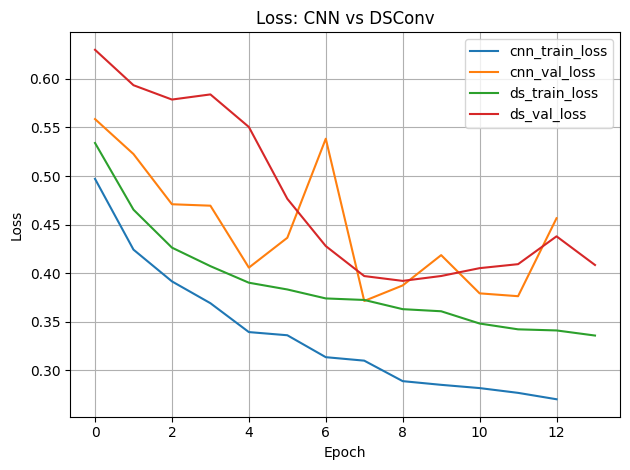

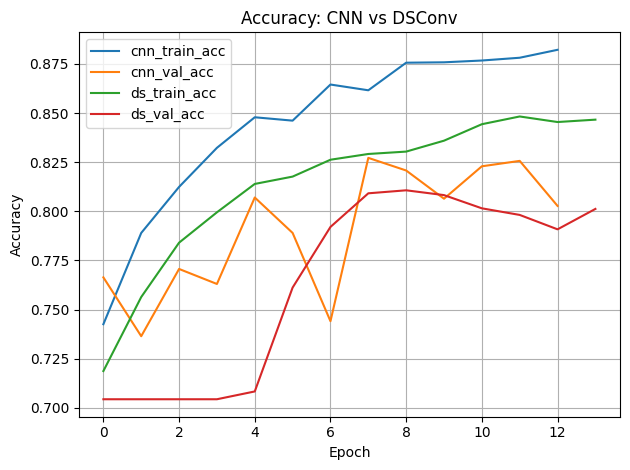

In [ ]:
# =========================
# Main (Traditional CNN vs DSConv) + comparison
# =========================
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

cfg.seed = 42
cfg.task = "binary"
cfg.filter_type = "hp1"
cfg.num_blocks = 3  # choose 1,2,3,...

def set_global_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def _print_result(tag: str, model, res: dict):
    print(f"\n=== {tag} ===")
    model.summary()
    print(f"Test: acc={res['test_acc']:.4f}, f1={res['test_f1']:.4f}")
    print("Confusion matrix:\n", res["cm"])
    print(res["report"])

def _plot_histories(hist_cnn, hist_ds, *, out_dir: str = None, show: bool = True):
    """Overlay CNN vs DSConv curves for loss and accuracy."""
    # --- Loss plot ---
    plt.figure()
    plt.plot(hist_cnn.history["loss"], label="cnn_train_loss")
    plt.plot(hist_cnn.history["val_loss"], label="cnn_val_loss")
    plt.plot(hist_ds.history["loss"], label="ds_train_loss")
    plt.plot(hist_ds.history["val_loss"], label="ds_val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss: CNN vs DSConv")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if out_dir:
        plt.savefig(os.path.join(out_dir, "loss_cnn_vs_dsconv.png"), dpi=200)
    if show:
        plt.show()
    plt.close()

    # --- Accuracy plot ---
    plt.figure()
    plt.plot(hist_cnn.history.get("accuracy", []), label="cnn_train_acc")
    plt.plot(hist_cnn.history.get("val_accuracy", []), label="cnn_val_acc")
    plt.plot(hist_ds.history.get("accuracy", []), label="ds_train_acc")
    plt.plot(hist_ds.history.get("val_accuracy", []), label="ds_val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy: CNN vs DSConv")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if out_dir:
        plt.savefig(os.path.join(out_dir, "acc_cnn_vs_dsconv.png"), dpi=200)
    if show:
        plt.show()
    plt.close()

def _print_comparison_table(res_cnn: dict, res_ds: dict):
    """Small text comparison with deltas."""
    acc_c, f1_c = res_cnn["test_acc"], res_cnn["test_f1"]
    acc_d, f1_d = res_ds["test_acc"], res_ds["test_f1"]
    print("\n=== Summary (Test) ===")
    print(f"CNN   : acc={acc_c:.4f}, f1={f1_c:.4f}")
    print(f"DSConv: acc={acc_d:.4f}, f1={f1_d:.4f}")
    print(f"Delta : acc={acc_d-acc_c:+.4f}, f1={f1_d-f1_c:+.4f}")

def main():
    set_global_seed(cfg.seed)

    # (X_train, y_train), (X_val, y_val), (X_test, y_test) = build_split_arrays(cfg.data_root)

    print("\n=== Classical baselines (PPG features) ===")
    classical_results = train_eval_classical(X_train, y_train, X_val, y_val, X_test, y_test)
    for name, res in classical_results.items():
        print(f"\n[{name}]")
        print(f"Val:  acc={res['val_acc']:.4f}, f1={res['val_f1']:.4f}")
        print(f"Test: acc={res['test_acc']:.4f}, f1={res['test_f1']:.4f}")
        print("Confusion matrix:\n", res["cm"])
        print(res["report"])

    print("\n=== Small deep model (PPG raw windows): CNN vs DSConv ===")

    # --- Train/eval traditional CNN ---
    model_cnn, hist_cnn, res_cnn = train_eval_cnn(
        X_train, y_train, X_val, y_val, X_test, y_test,
        cfg.num_blocks,
        conv_type="standard"
    )

    # --- Train/eval DSConv variant ---
    model_ds, hist_ds, res_ds = train_eval_cnn(
        X_train, y_train, X_val, y_val, X_test, y_test,
        cfg.num_blocks,
        conv_type="dsconv"
    )

    # --- Print each ---
    _print_result("Traditional CNN", model_cnn, res_cnn)
    _print_result("DSConv CNN", model_ds, res_ds)

    # --- Compare ---
    _print_comparison_table(res_cnn, res_ds)

    # --- Plot overlay curves (optional save) ---
    out_dir = None  # e.g., "./results"
    # if out_dir: os.makedirs(out_dir, exist_ok=True)
    _plot_histories(hist_cnn, hist_ds, out_dir=out_dir, show=True)

    return model_cnn, model_ds, res_cnn, res_ds


if __name__ == "__main__":
    model_cnn, model_ds, res_cnn, res_ds = main()



=== Train/Eval: Baseline vs SE ===
MEAN = 0.003933
STD  = 57.558952
Epoch 1/50
78/78 - 10s - loss: 0.4430 - accuracy: 0.7740 - val_loss: 0.5699 - val_accuracy: 0.7044 - lr: 0.0010 - 10s/epoch - 133ms/step
Epoch 2/50
78/78 - 1s - loss: 0.3229 - accuracy: 0.8578 - val_loss: 0.5301 - val_accuracy: 0.7023 - lr: 0.0010 - 1s/epoch - 17ms/step
Epoch 3/50
78/78 - 1s - loss: 0.2715 - accuracy: 0.8818 - val_loss: 0.5429 - val_accuracy: 0.7359 - lr: 0.0010 - 1s/epoch - 17ms/step
Epoch 4/50
78/78 - 2s - loss: 0.2593 - accuracy: 0.8867 - val_loss: 0.7315 - val_accuracy: 0.6388 - lr: 0.0010 - 2s/epoch - 22ms/step
Epoch 5/50
78/78 - 1s - loss: 0.2284 - accuracy: 0.9005 - val_loss: 0.4316 - val_accuracy: 0.7921 - lr: 0.0010 - 1s/epoch - 17ms/step
Epoch 6/50
78/78 - 1s - loss: 0.2212 - accuracy: 0.9026 - val_loss: 0.6219 - val_accuracy: 0.7282 - lr: 0.0010 - 741ms/epoch - 10ms/step
Epoch 7/50

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
78/78 - 1s - loss: 0.1977 - accur

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== [se] Robustness: Random missing data sweep ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


=== [se] Robustness: Burst missing data sweep ===

Saved: robustness_runs/robustness_sweeps_base_vs_se.csv


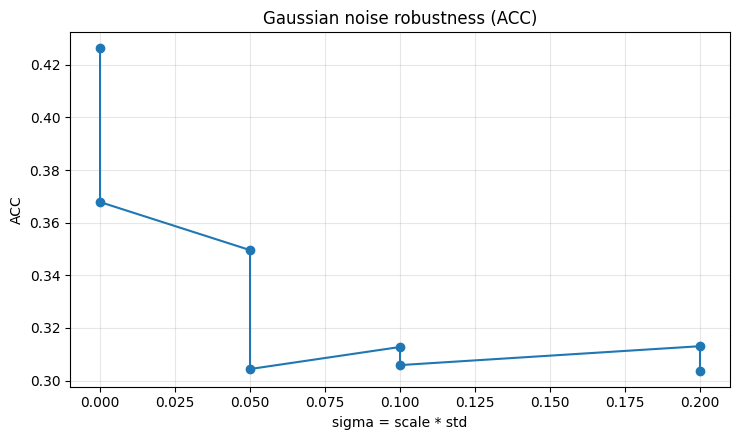

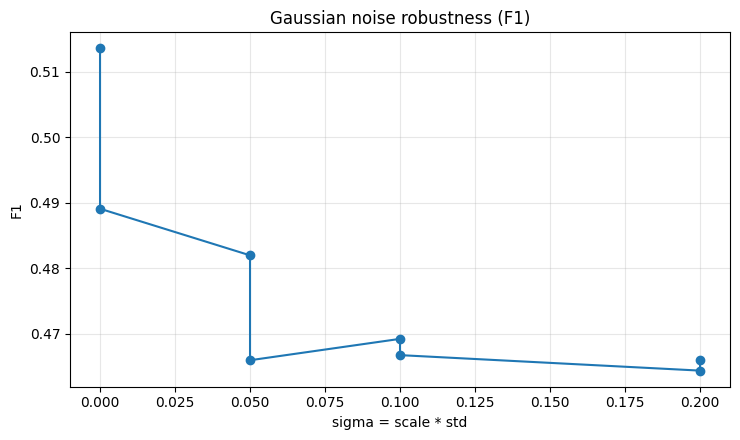

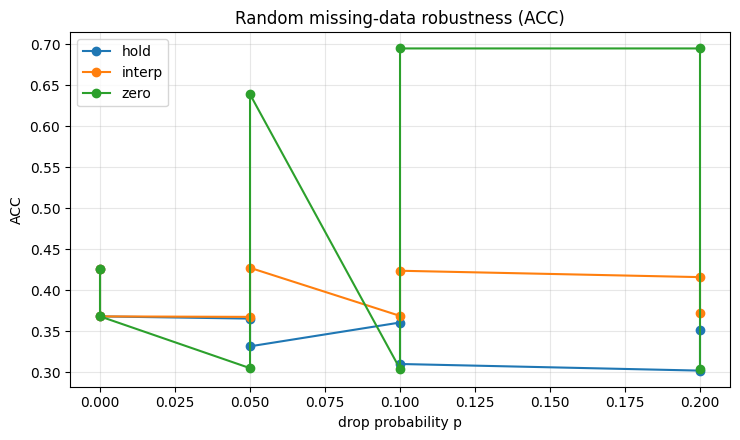

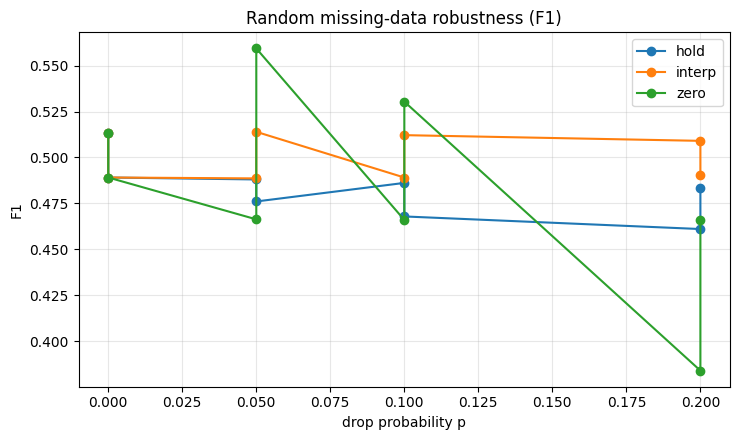

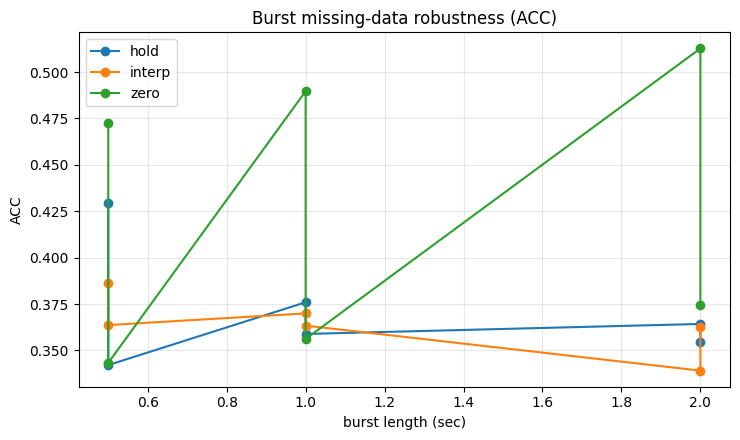

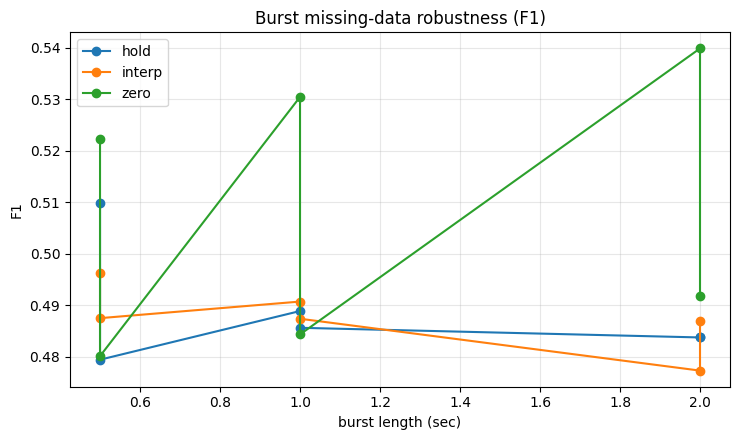

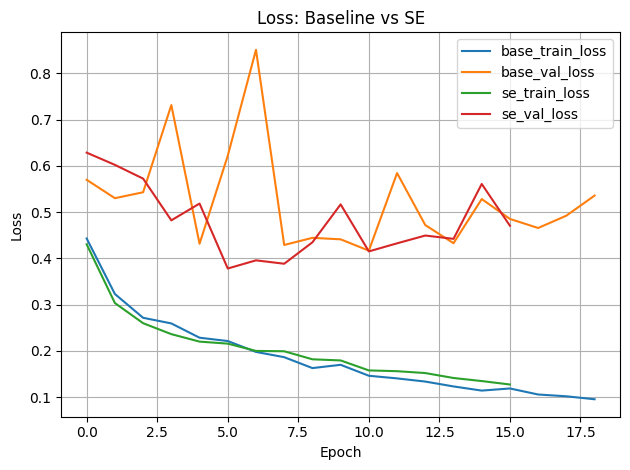

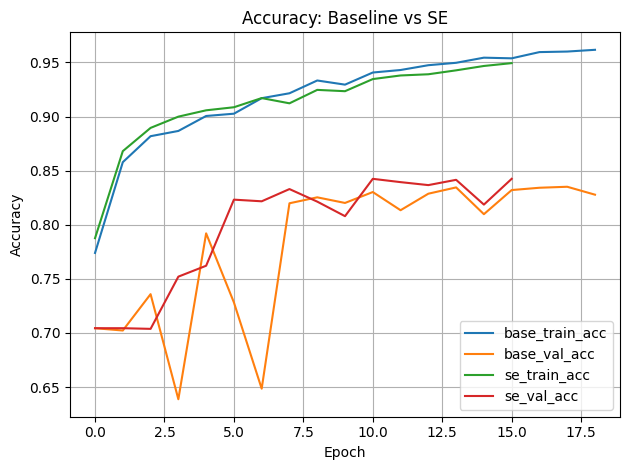

In [ ]:
# =========================
# Robustness experiment: compare Baseline vs SE
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

cfg.seed = 42
cfg.task = "binary"
cfg.filter_type = "hp1"
cfg.num_blocks = 4  # choose 1,2,3,4 etc.

FS_FIXED = 64  # must match how your windows were built

sigma_scales = (0.0, 0.05, 0.1, 0.2)
drop_ps      = (0.0, 0.05, 0.1, 0.2)
burst_secs   = (0.5, 1.0, 2.0)
modes        = ("zero", "hold", "interp")


def _ensure_3d(X):
    """Make sure inputs are (B,T,1) as your CNN expects."""
    if X.ndim == 2:
        return X[..., None]
    return X


def _tag_df(df: pd.DataFrame, *, model_tag: str) -> pd.DataFrame:
    df = df.copy()
    df["model"] = model_tag
    return df


def run_robustness_sweeps(model, X_test, y_test, *, model_tag: str, seed: int):
    """Run all sweeps for one model and return a combined dataframe."""
    print(f"\n=== [{model_tag}] Robustness: Gaussian noise sweep ===")
    df_gauss = sweep_gaussian(model, X_test, y_test, sigma_scales=sigma_scales, seed=seed)
    df_gauss = _tag_df(df_gauss, model_tag=model_tag)

    print(f"\n=== [{model_tag}] Robustness: Random missing data sweep ===")
    df_rand = sweep_random_drop(model, X_test, y_test, drop_ps=drop_ps, modes=modes, seed=seed)
    df_rand = _tag_df(df_rand, model_tag=model_tag)

    print(f"\n=== [{model_tag}] Robustness: Burst missing data sweep ===")
    df_burst = sweep_burst_drop(model, X_test, y_test, burst_secs=burst_secs, fs=FS_FIXED, modes=modes, seed=seed)
    df_burst = _tag_df(df_burst, model_tag=model_tag)

    return pd.concat([df_gauss, df_rand, df_burst], ignore_index=True)


def main():
    # (X_train, y_train), (X_val, y_val), (X_test, y_test) = build_split_arrays(cfg.data_root)

    print("\n=== Train/Eval: Baseline vs SE ===")

    # ---- Train baseline ----
    model_base, hist_base, res_base = train_eval_cnn(
        X_train, y_train, X_val, y_val, X_test, y_test,
        cfg.num_blocks,
        use_se=False,
        verbose=2
    )
    print("\n[Baseline] Clean Test:",
          f"acc={res_base['test_acc']:.4f}, f1={res_base['test_f1']:.4f}")

    # ---- Train SE ----
    model_se, hist_se, res_se = train_eval_cnn(
        X_train, y_train, X_val, y_val, X_test, y_test,
        cfg.num_blocks,
        use_se=True,
        se_ratio=16,
        se_after="act",
        verbose=2
    )
    print("\n[SE] Clean Test:",
          f"acc={res_se['test_acc']:.4f}, f1={res_se['test_f1']:.4f}")

    # ---- Prepare test inputs for sweeps ----
    # NOTE: if your sweep_* functions expect raw (B,T) and do their own channel add,
    # then keep X_test as-is. If they call model.predict, they likely need (B,T,1).
    X_test_cnn = _ensure_3d(X_test).astype(np.float32)

    # -----------------------------
    # Robustness sweeps (TEST set)
    # -----------------------------
    df_base = run_robustness_sweeps(model_base, X_test_cnn, y_test, model_tag="base", seed=cfg.seed)
    df_se   = run_robustness_sweeps(model_se,   X_test_cnn, y_test, model_tag="se",   seed=cfg.seed)

    df_all = pd.concat([df_base, df_se], ignore_index=True)

    # Save tables
    outdir = "robustness_runs"
    os.makedirs(outdir, exist_ok=True)
    csv_path = os.path.join(outdir, "robustness_sweeps_base_vs_se.csv")
    df_all.to_csv(csv_path, index=False)
    print(f"\nSaved: {csv_path}")

    # Plots (update your plot_sweeps to use 'model' column for legend/grouping)
    plot_sweeps(df_all, outdir=outdir)

    # -----------------------------
    # Training curves (optional)
    # -----------------------------
    # Loss overlay
    plt.figure()
    plt.plot(hist_base.history["loss"], label="base_train_loss")
    plt.plot(hist_base.history["val_loss"], label="base_val_loss")
    plt.plot(hist_se.history["loss"], label="se_train_loss")
    plt.plot(hist_se.history["val_loss"], label="se_val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss: Baseline vs SE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Accuracy overlay
    plt.figure()
    plt.plot(hist_base.history.get("accuracy", []), label="base_train_acc")
    plt.plot(hist_base.history.get("val_accuracy", []), label="base_val_acc")
    plt.plot(hist_se.history.get("accuracy", []), label="se_train_acc")
    plt.plot(hist_se.history.get("val_accuracy", []), label="se_val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy: Baseline vs SE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model_base, model_se, df_all, res_base, res_se


if __name__ == "__main__":
    model_base, model_se, df_all, res_base, res_se = main()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = [
    [384, 1, 64, 6.0, 36.20196078431373, 435.9246274509804, 0.1672666666666667, 63.39980392156863, 1.0, 51],
    [384, 2, 64, 12.0, 33.423529411764704, 370.08901960784317, 0.1399921568627451, 63.45, 1.4901960784313726, 51],
    [384, 4, 64, 24.0, 29.539215686274513, 277.55554901960784, 0.10163137254901962, 63.5913725490196, 2.4705882352941178, 51],
    [384, 8, 64, 48.0, 26.235294117647058, 199.1160980392157, 0.06915490196078432, 63.663529411764706, 4.235294117647059, 51],
]
cols = ["hop","batch","fs","latency_s","active_mean","eproxy_ms_s_mean","inf_s_mean","samp_s_mean","pend_peak_mean","n_pwr_windows"]
df = pd.DataFrame(data, columns=cols).sort_values("batch")

x_labels = df["batch"].astype(int).tolist()
x = np.arange(len(x_labels))

series = [
    ("active_mean", "active"),
    ("eproxy_ms_s_mean", "eproxy_ms_s"),
    ("inf_s_mean", "inf"),
    ("samp_s_mean", "samp"),
    ("pend_peak_mean", "pend_peak"),
]

bar_w = 0.13
fig, ax = plt.subplots(figsize=(12, 5.5))

for i, (col, label) in enumerate(series):
    ax.bar(x + (i - (len(series)-1)/2) * bar_w, df[col].values, width=bar_w, label=label)

ax.set_title("MCU resource proxies vs Batch (from [PWR] logs)")
ax.set_xlabel("Batch")
ax.set_ylabel("Value (mean over PWR windows)")
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.legend(ncol=3, loc="upper left")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

csv = """burst,fs,hop,batch,active_mean,rx_ms_s_mean,infer_ms_s_mean,fill_ms_s_mean,eproxy_ms_s_mean,samp_s_mean,inf_s_mean,pend_peak_mean,n_pwr_windows
1,64,384,1,35.43333333333333,230.2188431372549,197.53217647058824,0.07258823529411766,427.82364705882355,63.600392156862746,0.16748627450980394,1.0,51
8,64,384,1,34.78846153846155,231.0839423076923,196.6027115384616,0.07536538461538463,427.76207692307696,63.31692307692309,0.16675384615384614,0.9807692307692307,52
16,64,384,1,34.74237288135593,232.11242372881355,196.28115254237287,0.0783220338983051,428.4719152542372,63.362881355932196,0.16650677966101696,0.864406779661017,59
64,64,384,1,34.411864406779664,229.2337627118644,190.87467796610167,0.07167796610169491,420.1799830508475,61.43898305084746,0.1620152542372881,0.847457627118644,59
256,64,384,1,34.04666666666666,225.18433333333334,186.38639999999998,0.06885,411.63953333333336,60.499166666666675,0.15821499999999997,0.75,60
"""

df = pd.read_csv(StringIO(csv)).sort_values("burst")

x_labels = df["burst"].astype(int).tolist()
x = np.arange(len(x_labels))

series = [
    ("active_mean", "active"),
    ("rx_ms_s_mean", "rx_ms_s"),
    ("infer_ms_s_mean", "infer_ms_s"),
    ("eproxy_ms_s_mean", "eproxy_ms_s"),
    ("samp_s_mean", "samp_s"),
    ("pend_peak_mean", "pend_peak"),
]

bar_w = 0.12
fig, ax = plt.subplots(figsize=(13, 5.5))

for i, (col, label) in enumerate(series):
    ax.bar(x + (i - (len(series)-1)/2) * bar_w, df[col].values, width=bar_w, label=label)

ax.set_title("MCU resource proxies vs Burst (hop=384, fs=64, batch=1)")
ax.set_xlabel("Burst")
ax.set_ylabel("Value (mean over PWR windows)")
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.legend(ncol=3, loc="upper left")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data provided by user: mean ± std for each mode
text_mode = {
    "label": "TEXT",
    "active": (34.04666666666666, 10.18034774582817),
    "infer_ms_s": (186.38639999999998, 115.52639285494278),
    "fill_ms_s": (0.06885, 0.04280021582394499),
    "rx_ms_s": (225.18433333333334, 121.20403395530839),
    "eproxy_ms_s": (411.63953333333336, 236.4981116145963),
    "samp": (60.499166666666675, 19.878800162584128),
    "inf": (0.15821499999999997, 0.09806716623427202),
    "dt": (5.085999999999999, 0.2786723974216782),
    "pend_peak": (0.75, 0.4366668823046865),
}

bin_f32 = {
    "label": "BIN_F32",
    "active": (26.675875486381322, 20.70395025977979),
    "infer_ms_s": (116.8710972762646, 235.34438656532026),
    "fill_ms_s": (0.042708171206225685, 0.0861787548328071),
    "rx_ms_s": (131.899233463035, 247.77649999463975),
    "eproxy_ms_s": (248.81299610894942, 482.7191802989561),
    "samp": (50.59256809338522, 84.20475945725475),
    "inf": (0.0992124513618677, 0.19978500827604154),
    "dt": (1.1985214007782101, 0.399768673990697),
    "pend_peak": (0.19844357976653695, 0.39960614121079924),
}

int8 = {
    "label": "INT8",
    "active": (18.693307086614176, 12.222877309840428),
    "infer_ms_s": (22.39483464566929, 144.28736651545293),
    "fill_ms_s": (0.008188976377952756, 0.05276223530933261),
    "rx_ms_s": (36.24374803149606, 146.44395394056573),
    "eproxy_ms_s": (58.64677165354332, 289.7674201275951),
    "samp": (62.93877952755905, 110.73477125504762),
    "inf": (0.019003149606299213, 0.1224351056227543),
    "dt": (1.2113385826771654, 1.3616665342591419),
    "pend_peak": (0.8700787401574803, 2.043704880369046),
}

modes = [text_mode, bin_f32, int8]

# Metrics to plot (keep same ordering as your table, and focus on resource proxies)
metrics = ["active", "rx_ms_s", "infer_ms_s", "eproxy_ms_s", "samp", "inf", "dt", "pend_peak"]
metric_labels = metrics

x = np.arange(len(metrics))
bar_w = 0.23

fig, ax = plt.subplots(figsize=(14, 6))

for i, mode in enumerate(modes):
    means = [mode[m][0] for m in metrics]
    stds  = [mode[m][1] for m in metrics]
    ax.bar(
        x + (i - (len(modes)-1)/2) * bar_w,
        means,
        width=bar_w,
        yerr=stds,
        capsize=4,
        label=mode["label"],
    )

ax.set_title("Resource proxies comparison (mean ± std): TEXT vs BIN_F32 vs INT8")
ax.set_xlabel("Metric")
ax.set_ylabel("Value")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, rotation=0)
ax.legend(loc="upper left", ncol=3)

plt.tight_layout()
plt.show()


In [ ]:
print("model =", model_ds)
print("type(model) =", type(model_ds))

model = <tf_keras.src.engine.functional.Functional object at 0x7cd0b42bbef0>
type(model) = <class 'tf_keras.src.engine.functional.Functional'>


In [ ]:

tflite_model_name = "1D_DS_CNN_Float"

converter = tf.lite.TFLiteConverter.from_keras_model(model_ds)
#converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(f"{tflite_model_name}.tflite", "wb") as f:
    f.write(tflite_model)


In [ ]:
from pathlib import Path

def hex_to_c_array(model_bytes: bytes, var_name: str) -> str:
    safe_name = "".join(ch if (ch.isalnum() or ch == "_") else "_" for ch in var_name)
    if safe_name and safe_name[0].isdigit():
        safe_name = "_" + safe_name

    guard = safe_name.upper() + "_H"

    c_str = ""
    c_str += f"#ifndef {guard}\n#define {guard}\n\n"
    c_str += "#include <stdint.h>\n\n"

    # IMPORTANT: const so it goes to Flash, not RAM
    c_str += f"const unsigned int {safe_name}_len = {len(model_bytes)};\n"
    c_str += f"alignas(16) const unsigned char {safe_name}[] = {{\n "

    for i, val in enumerate(model_bytes):
        c_str += f"0x{val:02x}"
        if i != len(model_bytes) - 1:
            c_str += ", "
        if (i + 1) % 12 == 0:
            c_str += "\n "

    c_str += "\n};\n\n"
    c_str += f"#endif // {guard}\n"
    return c_str

In [ ]:
##### Start week 4 #####
def representative_dataset_gen(X_calib, n=300):
    X_calib = X_calib[:n]
    for i in range(len(X_calib)):
        yield [X_calib[i:i+1].astype(np.float32)]

def convert_int8_internal_float_io(keras_model, X_train, out_path="1D_CNN_int8_floatio.tflite"):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = lambda: representative_dataset_gen(X_train, n=300)

    # Force int8 kernels internally
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

    # converter.inference_input_type  = tf.int8
    # converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open(out_path, "wb") as f:
        f.write(tflite_model)

    return out_path


In [ ]:
def normalize_and_add_channel(X, mean, std):
    Xn = (X - mean) / (std + 1e-8)
    if Xn.ndim == 2:
        Xn = Xn[..., None]  # (N,512) -> (N,512,1)
    return Xn.astype(np.float32)

def ensure_3d(X):
    X = np.asarray(X)
    if X.ndim == 2:          # (N,512) -> (N,512,1)
        X = X[..., None]
    return X.astype(np.float32)


mean = np.mean(X_train)
std  = np.std(X_train) + 1e-8

X_train = normalize_and_add_channel(X_train, mean, std)
X_test = normalize_and_add_channel(X_test, mean, std)
X_val = normalize_and_add_channel(X_val, mean, std)

X_train = ensure_3d(X_train)
X_test = ensure_3d(X_test)
X_val = ensure_3d(X_val)

print(X_train.shape, X_train.dtype)
print(X_val.shape, X_val.dtype)
print(X_test.shape, X_test.dtype)  # should be (N,512,1) float32
print(model_ds.input_shape)             # should be (None,512,1)

(9910, 512, 1) float32
(3275, 512, 1) float32
(3341, 512, 1) float32
(None, 512, 1)


In [ ]:
int8_path = convert_int8_internal_float_io(model_ds, X_test, "1D_DS_CNN_int8.tflite")
print("Saved:", int8_path)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved: 1D_DS_CNN_int8.tflite


In [ ]:

interp = tf.lite.Interpreter(model_path="1D_DS_CNN_int8.tflite")
interp.allocate_tensors()
print("Input dtype:",  interp.get_input_details()[0]["dtype"])
print("Output dtype:", interp.get_output_details()[0]["dtype"])

# Check that there are int8 tensors inside (good sign)
any_int8 = any(d["dtype"] == np.int8 for d in interp.get_tensor_details())
print("Has int8 tensors inside:", any_int8)

Input dtype: <class 'numpy.float32'>
Output dtype: <class 'numpy.float32'>
Has int8 tensors inside: True


In [ ]:
import os

def model_file_size_kb(path):
    return os.path.getsize(path) / 1024.0

print("Float TFLite size (KB):", model_file_size_kb("1D_DS_CNN_Float.tflite"))
print("INT8  TFLite size (KB):", model_file_size_kb("1D_DS_CNN_int8.tflite"))


Float TFLite size (KB): 36.87890625
INT8  TFLite size (KB): 23.2109375


In [ ]:
float_bytes = Path("1D_DS_CNN_Float.tflite").read_bytes()
int8_bytes  = Path("1D_DS_CNN_int8.tflite").read_bytes()

print("float len:", len(float_bytes), "bytes")
print("int8  len:", len(int8_bytes), "bytes")

Path("cnn_1d_float.h").write_text(hex_to_c_array(float_bytes, "cnn_1d_float"))
Path("cnn_1d_int8.h").write_text(hex_to_c_array(int8_bytes,  "cnn_1d_int8"))

float len: 37764 bytes
int8  len: 23768 bytes


146756

In [ ]:
def _quantize(x_fp32, scale, zero_point, dtype):
    # dtype is np.int8 or np.uint8
    if scale == 0:
        raise ValueError("Quantization scale is 0 (unexpected).")
    x_q = np.round(x_fp32 / scale + zero_point)
    if dtype == np.int8:
        x_q = np.clip(x_q, -128, 127).astype(np.int8)
    else:
        x_q = np.clip(x_q, 0, 255).astype(np.uint8)
    return x_q

def _dequantize(x_q, scale, zero_point):
    return (x_q.astype(np.float32) - zero_point) * scale

def tflite_predict(
    tflite_path,
    X,
    mode="auto",            # "auto" | "softmax" | "sigmoid"
    batch_size=64,
    return_probs=False
):
    """
    Predict with a TFLite model (float or quantized).
    - mode="softmax": argmax over last dim
    - mode="sigmoid": threshold at 0.5
    - mode="auto": if output last-dim > 1 => softmax else sigmoid
    Returns: y_pred (N,), and optionally probs/logits in float.
    """
    X = np.asarray(X)
    if X.ndim == 2:
        X = X[..., None]  # ensure (N,512,1)
    X = X.astype(np.float32)

    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    in_det  = interpreter.get_input_details()[0]
    out_det = interpreter.get_output_details()[0]

    in_idx  = in_det["index"]
    out_idx = out_det["index"]

    in_dtype  = in_det["dtype"]
    out_dtype = out_det["dtype"]

    in_scale,  in_zero  = in_det["quantization"]   # (0,0) for float
    out_scale, out_zero = out_det["quantization"]

    # Determine output class mode
    out_shape = out_det["shape"]  # e.g. (1,2) or (1,1)
    out_dim = int(out_shape[-1]) if len(out_shape) >= 2 else 1
    if mode == "auto":
        mode = "softmax" if out_dim > 1 else "sigmoid"
    if mode not in ("softmax", "sigmoid"):
        raise ValueError("mode must be 'auto', 'softmax', or 'sigmoid'")

    N = X.shape[0]
    preds = []
    probs_all = [] if return_probs else None

    # Batch loop
    for start in range(0, N, batch_size):
        xb = X[start:start+batch_size]
        b = xb.shape[0]

        # Resize interpreter input to this batch size (once per batch size change)
        # This makes it much faster than single-sample loops.
        interpreter.resize_tensor_input(in_idx, [b] + list(in_det["shape"][1:]))
        interpreter.allocate_tensors()

        # Quantize input if needed
        if in_dtype in (np.int8, np.uint8):
            xb_in = _quantize(xb, in_scale, in_zero, in_dtype)
        else:
            xb_in = xb.astype(in_dtype)

        interpreter.set_tensor(in_idx, xb_in)
        interpreter.invoke()

        yb = interpreter.get_tensor(out_idx)  # shape (b, out_dim) or (b,1)

        # Dequantize output if needed
        if out_dtype in (np.int8, np.uint8) and out_scale != 0:
            yb = _dequantize(yb, out_scale, out_zero)

        # Convert to predicted label
        if mode == "sigmoid":
            p = np.squeeze(yb)              # (b,) or scalar
            y_pred = (p >= 0.5).astype(np.int32).reshape(-1)
            if return_probs:
                probs_all.append(p.reshape(-1, 1))
        else:
            # softmax/logits (b, C)
            y_pred = np.argmax(yb, axis=-1).astype(np.int32).reshape(-1)
            if return_probs:
                probs_all.append(yb.astype(np.float32))

        preds.append(y_pred)

    y_pred = np.concatenate(preds, axis=0)
    if return_probs:
        probs = np.concatenate(probs_all, axis=0)
        return y_pred, probs
    return y_pred

def eval_tflite(
    tflite_path,
    X_test,
    y_test,
    mode="softmax",     # for your model, explicitly softmax
    batch_size=64
):
    y_test = np.asarray(y_test).astype(np.int32).reshape(-1)
    y_pred = tflite_predict(tflite_path, X_test, mode=mode, batch_size=batch_size, return_probs=False)

    acc = float((y_pred == y_test).mean())

    from sklearn.metrics import confusion_matrix, classification_report, f1_score
    cm = confusion_matrix(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    rep = classification_report(y_test, y_pred, digits=4)

    return {"acc": acc, "f1": float(f1), "cm": cm, "report": rep}


In [ ]:
#1) evaluate float and int8 TFLite
res_float = eval_tflite("1D_CNN_Float.tflite", X_val, y_val, mode="softmax", batch_size=64)
res_int8  = eval_tflite("1D_CNN_int8.tflite", X_val, y_val, mode="softmax", batch_size=64)

print("Float acc:", res_float["acc"], "f1:", res_float["f1"])
print("Int8  acc:", res_int8["acc"],  "f1:", res_int8["f1"])
print("Float CM:\n", res_float["cm"])
print("Int8 CM:\n", res_int8["cm"])
print(res_int8["report"])


In [ ]:
!pip -q install tensorflow-model-optimization


In [ ]:
import tensorflow_model_optimization as tfmot
def prune_and_finetune(
    base_model,
    X_train, y_train,
    X_val, y_val,
    epochs=8,
    batch_size=128,
    final_sparsity=0.6,
    initial_sparsity=0.0,
    lr=1e-4
):
    # Number of training steps
    steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
    end_step = steps_per_epoch * epochs

    pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=initial_sparsity,
        final_sparsity=final_sparsity,
        begin_step=0,
        end_step=end_step
    )

    prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

    # Wrap the model for pruning
    pruned_model = prune_low_magnitude(base_model, pruning_schedule=pruning_schedule)

    pruned_model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        tfmot.sparsity.keras.UpdatePruningStep(),
        tfmot.sparsity.keras.PruningSummaries(log_dir="./prune_logs"),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ]

    history = pruned_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=2
    )

    # Strip pruning wrappers for export/inference
    stripped_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

    return stripped_model, history

In [ ]:
unstruct_pruned_model, pruned_hist = prune_and_finetune(
    model,
    X_train, y_train,
    X_val, y_val,
    epochs=10,
    batch_size=64,
    final_sparsity=0.8,
    lr=1e-4
)


In [ ]:
tflite_model_name = "1D_CNN_unstruct_pruned_Float"

converter = tf.lite.TFLiteConverter.from_keras_model(unstruct_pruned_model)
#converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(f"{tflite_model_name}.tflite", "wb") as f:
    f.write(tflite_model)

In [ ]:
int8_unstruct_pruned_path = convert_int8_internal_float_io(unstruct_pruned_model, X_test, "1D_CNN_unstruct_pruned_int8.tflite")
print("Saved:", int8_unstruct_pruned_path)

In [ ]:
float_unstruct_pruned_bytes = Path("1D_CNN_unstruct_pruned_Float.tflite").read_bytes()
int8_unstruct_pruned_bytes  = Path("1D_CNN_unstruct_pruned_int8.tflite").read_bytes()

print("float len:", len(float_bytes), "bytes")
print("int8  len:", len(int8_bytes), "bytes")

Path("cnn_1d_unstruct_pruned_float.h").write_text(hex_to_c_array(float_bytes, "1D_CNN_unstruct_pruned_Float"))
Path("cnn_1d_unstruct_pruned_int8.h").write_text(hex_to_c_array(int8_bytes,  "1D_CNN_unstruct_pruned_int8"))

In [ ]:
#1) evaluate float and int8 TFLite
res_float = eval_tflite("1D_CNN_unstruct_pruned_Float.tflite", X_val, y_val, mode="softmax", batch_size=64)
res_int8  = eval_tflite("1D_CNN_unstruct_pruned_int8.tflite", X_val, y_val, mode="softmax", batch_size=64)

print("Float acc:", res_float["acc"], "f1:", res_float["f1"])
print("Int8  acc:", res_int8["acc"],  "f1:", res_int8["f1"])
print("Float CM:\n", res_float["cm"])
print("Int8 CM:\n", res_int8["cm"])
print(res_int8["report"])

In [ ]:
import numpy as np
import tensorflow as tf

def _get_layer(model, name):
    try:
        return model.get_layer(name)
    except Exception:
        return None

def _topk_idx(vec, k):
    k = int(np.clip(k, 1, vec.shape[0]))
    idx = np.argsort(vec)[-k:]
    return np.sort(idx)

def _conv_out_importance_l1(kernel, bias=None):
    """
    kernel shape: (K, Cin, Cout)
    returns importance per Cout
    """
    imp = np.sum(np.abs(kernel), axis=(0, 1))  # (Cout,)
    if bias is not None:
        imp = imp + np.abs(bias)
    return imp

def _dense_unit_importance_l1(W, b=None):
    """
    W shape: (in_dim, units)  -> importance per unit (column)
    """
    imp = np.sum(np.abs(W), axis=0)  # (units,)
    if b is not None:
        imp = imp + np.abs(b)
    return imp

def build_pruned_from_base_arch(base_model, new_filters, new_fc_units=None, name_suffix="_struct_pruned"):
    """
    Rebuilds the same sequential architecture as base_model but with:
      - Conv1D filters replaced by new_filters[i]
      - fc units replaced by new_fc_units (if not None)
    Uses the *existing* layer configs for BN/Act/Pool/Dropout/GAP.
    """
    x_in = tf.keras.Input(shape=base_model.input_shape[1:], name="x_in")
    x = x_in

    n_blocks = len(new_filters)

    for i in range(1, n_blocks + 1):
        conv = _get_layer(base_model, f"conv_{i}")
        if conv is None:
            raise ValueError(f"Base model missing layer conv_{i}")

        conv_cfg = conv.get_config()
        conv_cfg["filters"] = int(new_filters[i - 1])
        new_conv = tf.keras.layers.Conv1D.from_config(conv_cfg)
        x = new_conv(x)

        bn = _get_layer(base_model, f"bn_{i}")
        if bn is not None:
            bn_cfg = bn.get_config()
            new_bn = tf.keras.layers.BatchNormalization.from_config(bn_cfg)
            x = new_bn(x)

        act = _get_layer(base_model, f"act_{i}")
        if act is not None:
            act_cfg = act.get_config()
            new_act = tf.keras.layers.Activation.from_config(act_cfg)
            x = new_act(x)
        else:
            # Fallback: if somehow act layer doesn't exist
            pass

        pool = _get_layer(base_model, f"pool_{i}")
        if pool is not None:
            pool_cfg = pool.get_config()
            new_pool = tf.keras.layers.MaxPooling1D.from_config(pool_cfg)
            x = new_pool(x)

    gap = _get_layer(base_model, "gap")
    if gap is None:
        raise ValueError("Base model missing layer 'gap' (GlobalAveragePooling1D)")
    gap_cfg = gap.get_config()
    new_gap = tf.keras.layers.GlobalAveragePooling1D.from_config(gap_cfg)
    x = new_gap(x)

    drop = _get_layer(base_model, "dropout")
    if drop is not None:
        drop_cfg = drop.get_config()
        new_drop = tf.keras.layers.Dropout.from_config(drop_cfg)
        x = new_drop(x)

    fc = _get_layer(base_model, "fc")
    if fc is None:
        raise ValueError("Base model missing layer 'fc' (Dense)")
    fc_cfg = fc.get_config()
    if new_fc_units is not None:
        fc_cfg["units"] = int(new_fc_units)
    new_fc = tf.keras.layers.Dense.from_config(fc_cfg)
    x = new_fc(x)

    ddrop = _get_layer(base_model, "dense_dropout")
    if ddrop is not None:
        ddrop_cfg = ddrop.get_config()
        new_ddrop = tf.keras.layers.Dropout.from_config(ddrop_cfg)
        x = new_ddrop(x)

    pred = _get_layer(base_model, "pred")
    if pred is None:
        raise ValueError("Base model missing layer 'pred' (Dense softmax)")
    pred_cfg = pred.get_config()
    new_pred = tf.keras.layers.Dense.from_config(pred_cfg)
    out = new_pred(x)

    pruned_model = tf.keras.Model(x_in, out, name=base_model.name + name_suffix)
    return pruned_model

def structural_prune_transfer_weights(
    base_model: tf.keras.Model,
    keep_ratio_conv=0.5,
    keep_ratio_fc=None,  # e.g. 0.5 to shrink fc, or None to keep fc size
):
    """
    One-shot channel pruning:
      - For each Conv1D: keep top-k output channels by L1 magnitude
      - Propagate kept channels into next conv's input channels
      - Slice BN parameters accordingly
    Returns: (pruned_model, keep_info)
    """
    # infer number of blocks from conv layer names conv_1..conv_n
    conv_layers = []
    i = 1
    while _get_layer(base_model, f"conv_{i}") is not None:
        conv_layers.append(_get_layer(base_model, f"conv_{i}"))
        i += 1
    n_blocks = len(conv_layers)
    if n_blocks == 0:
        raise ValueError("No conv_i layers found in base_model.")

    # Decide which channels to keep in each block
    keep_idx_per_block = []
    new_filters = []

    prev_keep_in = None  # channels kept from previous conv (to slice Cin when scoring)
    for b in range(1, n_blocks + 1):
        conv = _get_layer(base_model, f"conv_{b}")
        w = conv.get_weights()
        kernel = w[0]  # (K, Cin, Cout)
        bias = w[1] if len(w) > 1 else None

        # If previous conv was pruned, only those Cin will remain
        if prev_keep_in is not None:
            kernel_score = kernel[:, prev_keep_in, :]
        else:
            kernel_score = kernel

        Cout = kernel_score.shape[-1]
        k_keep = max(1, int(np.ceil(Cout * keep_ratio_conv)))
        imp = _conv_out_importance_l1(kernel_score, bias=bias)
        keep_out = _topk_idx(imp, k_keep)

        keep_idx_per_block.append(keep_out)
        new_filters.append(len(keep_out))
        prev_keep_in = keep_out

    # Optionally prune fc units
    fc_keep_idx = None
    new_fc_units = None
    if keep_ratio_fc is not None:
        fc = _get_layer(base_model, "fc")
        W, b = fc.get_weights()  # W: (in_dim, units)
        units = W.shape[1]
        k_keep = max(1, int(np.ceil(units * keep_ratio_fc)))
        imp = _dense_unit_importance_l1(W, b=b)
        fc_keep_idx = _topk_idx(imp, k_keep)
        new_fc_units = len(fc_keep_idx)

    # Rebuild pruned architecture
    pruned_model = build_pruned_from_base_arch(
        base_model=base_model,
        new_filters=new_filters,
        new_fc_units=new_fc_units
    )

    # ---- Transfer weights with slicing ----
    prev_keep_in = None
    for b in range(1, n_blocks + 1):
        base_conv = _get_layer(base_model, f"conv_{b}")
        new_conv  = _get_layer(pruned_model, f"conv_{b}")
        keep_out = keep_idx_per_block[b - 1]

        w = base_conv.get_weights()
        kernel = w[0]
        bias = w[1] if len(w) > 1 else None

        # slice Cin then Cout
        if prev_keep_in is not None:
            kernel = kernel[:, prev_keep_in, :]
        kernel = kernel[:, :, keep_out]

        if bias is not None:
            bias = bias[keep_out]
            new_conv.set_weights([kernel, bias])
        else:
            new_conv.set_weights([kernel])

        # BN slice (if present)
        base_bn = _get_layer(base_model, f"bn_{b}")
        new_bn  = _get_layer(pruned_model, f"bn_{b}")
        if base_bn is not None and new_bn is not None:
            gamma, beta, mean, var = base_bn.get_weights()
            new_bn.set_weights([
                gamma[keep_out], beta[keep_out], mean[keep_out], var[keep_out]
            ])

        prev_keep_in = keep_out

    # fc transfer (GAP means fc input dim == last conv channels)
    base_fc = _get_layer(base_model, "fc")
    new_fc  = _get_layer(pruned_model, "fc")
    W, b = base_fc.get_weights()

    # Slice fc input rows by last conv kept channels
    last_keep = keep_idx_per_block[-1]
    W = W[last_keep, :]

    if fc_keep_idx is not None:
        # prune fc units (columns)
        W = W[:, fc_keep_idx]
        b = b[fc_keep_idx]

    new_fc.set_weights([W, b])

    # pred transfer
    base_pred = _get_layer(base_model, "pred")
    new_pred  = _get_layer(pruned_model, "pred")
    Wp, bp = base_pred.get_weights()  # Wp: (fc_units, n_classes)

    if fc_keep_idx is not None:
        Wp = Wp[fc_keep_idx, :]
    # else same shape
    new_pred.set_weights([Wp, bp])

    keep_info = {
        "keep_idx_per_block": keep_idx_per_block,
        "new_filters": new_filters,
        "fc_keep_idx": fc_keep_idx,
        "new_fc_units": new_fc_units
    }
    return pruned_model, keep_info

def structural_prune_and_finetune(
    base_model,
    X_train, y_train,
    X_val, y_val,
    *,
    keep_ratio_conv=0.5,
    keep_ratio_fc=None,      # e.g. 0.5, or None to keep fc width
    epochs=8,
    batch_size=64,
    lr=1e-4,
):
    pruned_model, keep_info = structural_prune_transfer_weights(
        base_model,
        keep_ratio_conv=keep_ratio_conv,
        keep_ratio_fc=keep_ratio_fc,
    )

    pruned_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ]

    history = pruned_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=2
    )
    return pruned_model, history, keep_info


In [ ]:
struct_pruned_model, hist, keep_info = structural_prune_and_finetune(
    model,
    X_train, y_train,
    X_val, y_val,
    keep_ratio_conv=0.3,   # keep 50% filters in each conv block
    keep_ratio_fc=0.3,     # optional: keep 50% units in fc (or set None)
    epochs=10,
    batch_size=64,
    lr=1e-4
)

struct_pruned_model.summary()

In [ ]:
import numpy as np
import tensorflow as tf

def _to_numpy(x):
    return x.numpy() if hasattr(x, "numpy") else np.asarray(x)

def predict_labels(model, X, batch_size=256):
    """
    Returns:
      y_pred: predicted class indices (N,)
      y_prob: predicted probabilities (N, C)
    """
    y_prob = model.predict(X, batch_size=batch_size, verbose=0)
    y_prob = _to_numpy(y_prob)
    y_pred = np.argmax(y_prob, axis=-1).astype(int)
    return y_pred, y_prob

def confusion_matrix_np(y_true, y_pred, n_classes=None):
    y_true = _to_numpy(y_true).astype(int).reshape(-1)
    y_pred = _to_numpy(y_pred).astype(int).reshape(-1)
    if n_classes is None:
        n_classes = int(max(y_true.max(), y_pred.max()) + 1)
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def per_class_metrics_from_cm(cm, eps=1e-12):
    """
    cm[r, c] = count of true=r predicted=c
    returns dict with precision/recall/f1/support for each class and macro/weighted averages
    """
    cm = np.asarray(cm, dtype=np.float64)
    tp = np.diag(cm)
    support = cm.sum(axis=1)                # true count per class
    pred_count = cm.sum(axis=0)             # predicted count per class

    precision = tp / (pred_count + eps)
    recall    = tp / (support + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)

    macro = {
        "precision": float(np.mean(precision)),
        "recall":    float(np.mean(recall)),
        "f1":        float(np.mean(f1)),
    }
    weighted = {
        "precision": float(np.sum(precision * support) / (np.sum(support) + eps)),
        "recall":    float(np.sum(recall * support) / (np.sum(support) + eps)),
        "f1":        float(np.sum(f1 * support) / (np.sum(support) + eps)),
    }
    overall_acc = float(tp.sum() / (cm.sum() + eps))

    per_class = []
    for k in range(cm.shape[0]):
        per_class.append({
            "class": k,
            "precision": float(precision[k]),
            "recall": float(recall[k]),
            "f1": float(f1[k]),
            "support": int(support[k]),
        })

    return {
        "accuracy": overall_acc,
        "per_class": per_class,
        "macro_avg": macro,
        "weighted_avg": weighted,
    }

def format_classification_report(metrics, class_names=None):
    """
    Pretty-print like sklearn classification_report (without importing sklearn).
    """
    per_class = metrics["per_class"]
    n_classes = len(per_class)

    if class_names is None:
        class_names = [str(i) for i in range(n_classes)]
    else:
        class_names = [str(c) for c in class_names]

    lines = []
    lines.append("              precision    recall  f1-score   support")
    for i, row in enumerate(per_class):
        name = class_names[i][:12].ljust(12)
        lines.append(
            f"{name}      {row['precision']:.4f}    {row['recall']:.4f}    {row['f1']:.4f}   {row['support']:>7}"
        )

    lines.append("")
    lines.append(f"accuracy                           {metrics['accuracy']:.4f}   {sum(r['support'] for r in per_class):>7}")
    lines.append(
        f"macro avg        {metrics['macro_avg']['precision']:.4f}    {metrics['macro_avg']['recall']:.4f}    {metrics['macro_avg']['f1']:.4f}   {sum(r['support'] for r in per_class):>7}"
    )
    lines.append(
        f"weighted avg     {metrics['weighted_avg']['precision']:.4f}    {metrics['weighted_avg']['recall']:.4f}    {metrics['weighted_avg']['f1']:.4f}   {sum(r['support'] for r in per_class):>7}"
    )
    return "\n".join(lines)

def eval_keras_classifier(model, X, y, *, batch_size=256, class_names=None, return_probs=False):
    """
    Evaluates model and returns dict with:
      loss, acc, cm, report, y_pred (+ y_prob optional)
    """
    y_true = _to_numpy(y).astype(int).reshape(-1)

    # Keras evaluate (loss + accuracy as compiled)
    ev = model.evaluate(X, y, batch_size=batch_size, verbose=0)
    # If metrics=["accuracy"], ev = [loss, acc]
    loss = float(ev[0])
    acc = float(ev[1]) if len(ev) > 1 else None

    y_pred, y_prob = predict_labels(model, X, batch_size=batch_size)
    n_classes = y_prob.shape[-1]
    cm = confusion_matrix_np(y_true, y_pred, n_classes=n_classes)

    metrics = per_class_metrics_from_cm(cm)
    report = format_classification_report(metrics, class_names=class_names)

    out = {
        "loss": loss,
        "acc": metrics["accuracy"],  # derived from CM (should match Keras acc)
        "cm": cm,
        "metrics": metrics,
        "report": report,
        "y_pred": y_pred,
    }
    if return_probs:
        out["y_prob"] = y_prob
    return out


In [ ]:
# After you run:
# pruned_model, history, keep_info = structural_prune_and_finetune(...)

class_names = ["NORMAL", "SCARE"]  # change if needed

res_val  = eval_keras_classifier(struct_pruned_model, X_val,  y_val,  batch_size=64, class_names=class_names)
res_test = eval_keras_classifier(struct_pruned_model, X_test, y_test, batch_size=64, class_names=class_names)

print("=== PRUNED (VAL) ===")
print("loss:", res_val["loss"], "acc:", res_val["acc"])
print("CM:\n", res_val["cm"])
print(res_val["report"])

print("\n=== PRUNED (TEST) ===")
print("loss:", res_test["loss"], "acc:", res_test["acc"])
print("CM:\n", res_test["cm"])
print(res_test["report"])


In [ ]:
tflite_model_name = "1D_CNN_struct_pruned_Float"

converter = tf.lite.TFLiteConverter.from_keras_model(struct_pruned_model)
#converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(f"{tflite_model_name}.tflite", "wb") as f:
    f.write(tflite_model)

In [ ]:
int8_struct_pruned_path = convert_int8_internal_float_io(struct_pruned_model, X_test, "1D_CNN_struct_pruned_int8.tflite")
print("Saved:", int8_unstruct_pruned_path)

In [ ]:
float_bytes = Path("1D_CNN_struct_pruned_Float.tflite").read_bytes()
int8_bytes  = Path("1D_CNN_struct_pruned_int8.tflite").read_bytes()

print("float len:", len(float_bytes), "bytes")
print("int8  len:", len(int8_bytes), "bytes")

Path("cnn_1d_struct_pruned_float.h").write_text(hex_to_c_array(float_bytes, "1D_CNN_struct_pruned_Float"))
Path("cnn_1d_struct_pruned_int8.h").write_text(hex_to_c_array(int8_bytes,  "1D_CNN_struct_pruned_int8"))

In [ ]:
#1) evaluate float and int8 TFLite
res_float = eval_tflite("1D_CNN_struct_pruned_Float.tflite", X_val, y_val, mode="softmax", batch_size=64)
res_int8  = eval_tflite("1D_CNN_struct_pruned_int8.tflite", X_val, y_val, mode="softmax", batch_size=64)

print("Float acc:", res_float["acc"], "f1:", res_float["f1"])
print("Int8  acc:", res_int8["acc"],  "f1:", res_int8["f1"])
print("Float CM:\n", res_float["cm"])
print("Int8 CM:\n", res_int8["cm"])
print(res_int8["report"])

In [ ]:
teacher = model
teacher.trainable = False
student = build_cnn_1d(input_len=512, n_classes=2, n_blocks=2)

In [ ]:
class Distiller(tf.keras.Model):
    def __init__(self, student, teacher, temperature=3.0, alpha=0.7):
        super().__init__()
        self.student = student
        self.teacher = teacher
        self.temperature = temperature
        self.alpha = alpha

        self.student_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
        self.distill_loss_fn = tf.keras.losses.KLDivergence()

        self.acc = tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")

    def compile(self, optimizer):
        super().compile()
        self.optimizer = optimizer

    def train_step(self, data):
        x, y = data

        # Teacher predictions (no grad)
        teacher_probs = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_probs = self.student(x, training=True)

            # Hard-label loss
            student_loss = self.student_loss_fn(y, student_probs)

            # Soft-label loss (temperature-scaled)
            T = self.temperature
            teacher_soft = tf.nn.softmax(tf.math.log(tf.clip_by_value(teacher_probs, 1e-7, 1.0)) / T)
            student_soft = tf.nn.softmax(tf.math.log(tf.clip_by_value(student_probs, 1e-7, 1.0)) / T)

            distill_loss = self.distill_loss_fn(teacher_soft, student_soft) * (T * T)

            loss = self.alpha * distill_loss + (1.0 - self.alpha) * student_loss

        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))

        self.acc.update_state(y, student_probs)
        return {"loss": loss, "accuracy": self.acc.result(),
                "student_loss": student_loss, "distill_loss": distill_loss}

    def test_step(self, data):
        x, y = data
        student_probs = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, student_probs)
        self.acc.update_state(y, student_probs)
        return {"loss": student_loss, "accuracy": self.acc.result()}

In [ ]:
distiller = Distiller(student=student, teacher=teacher, temperature=3.0, alpha=0.7)
distiller.compile(optimizer=tf.keras.optimizers.Adam(1e-4))

hist = distiller.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=2),
    ],
    verbose=2
)
student.summary()

In [ ]:
student_model = distiller.student
print("Teacher:", teacher.evaluate(X_test, y_test, verbose=0))
print("Student:", student_model.evaluate(X_test, y_test, verbose=0))

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(student_model.predict(X_test, verbose=0), axis=1)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))


In [ ]:
tflite_model_name = "1D_CNN_distill_Float"

converter = tf.lite.TFLiteConverter.from_keras_model(student_model)
#converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(f"{tflite_model_name}.tflite", "wb") as f:
    f.write(tflite_model)

In [ ]:
int8_distill_path = convert_int8_internal_float_io(student_model, X_test, "1D_CNN_distill_int8.tflite")
print("Saved:", int8_distill_path)

In [ ]:
float_bytes = Path("1D_CNN_distill_Float.tflite").read_bytes()
int8_bytes  = Path("1D_CNN_distill_int8.tflite").read_bytes()

print("float len:", len(float_bytes), "bytes")
print("int8  len:", len(int8_bytes), "bytes")

Path("cnn_1d_distill_float.h").write_text(hex_to_c_array(float_bytes, "1D_CNN_distill_Float"))
Path("cnn_1d_distill_int8.h").write_text(hex_to_c_array(int8_bytes,  "1D_CNN_distill_int8"))

In [ ]:
#1) evaluate float and int8 TFLite
res_float = eval_tflite("1D_CNN_distill_Float.tflite", X_val, y_val, mode="softmax", batch_size=64)
res_int8  = eval_tflite("1D_CNN_distill_int8.tflite", X_val, y_val, mode="softmax", batch_size=64)

print("Float acc:", res_float["acc"], "f1:", res_float["f1"])
print("Int8  acc:", res_int8["acc"],  "f1:", res_int8["f1"])
print("Float CM:\n", res_float["cm"])
print("Int8 CM:\n", res_int8["cm"])
print(res_int8["report"])